# Bridging the two ICL mechanisms

## Version B — Per-prompt mechanism selection on Hendel tasks
Split Hendel prompts by whether they survive input corruption.
Test: does OI-head ablation hurt the *failing* prompts more than the *surviving* ones?

## Version A — Ambiguity continuum (country→capital vs largest city)
Vary fraction of ambiguous demos. Show that as ambiguity increases,
patching recovery drops and OI-head engagement rises.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import sys; sys.path.insert(0, '../..')
import torch, numpy as np, matplotlib.pyplot as plt, random, seaborn as sns
import pandas as pd, pickle
from collections import defaultdict
from tqdm import tqdm
from transformer_lens import HookedTransformer

try:
    from configs import MODEL_NAME
except ImportError:
    MODEL_NAME = 'meta-llama/Llama-3.2-3B'

%matplotlib inline
sns.set_context('notebook')

model = HookedTransformer.from_pretrained(MODEL_NAME, device='cuda', dtype=torch.float16)
model.eval()
n_layers = model.cfg.n_layers
n_heads  = model.cfg.n_heads
d_model  = model.cfg.d_model
PATTERN_FILTER = lambda name: 'attn.hook_pattern' in name
top10pct_n = max(1, int(0.10 * n_layers * n_heads))
all_pairs = [(L, h) for L in range(n_layers) for h in range(n_heads)]

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-26 08:16:38.375104: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.21it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer


In [2]:
# === Shared utilities (from oi_heads_2) ===

def build_icl_prompt(demo_pairs, query_input):
    lines = [f'{inp} \u2192 {out}' for inp, out in demo_pairs]
    lines.append(f'{query_input} \u2192')
    return '\n'.join(lines)

def find_per_demo_positions(model, prompt, demos):
    tokens = model.to_tokens(prompt, prepend_bos=True)[0]
    full_decoded = model.tokenizer.decode(tokens)
    char_to_tok = []
    for i in range(len(tokens)):
        s = model.tokenizer.decode([tokens[i].item()])
        char_to_tok.extend([i] * len(s))
    def span_to_toks(start, end):
        if start < 0 or end > len(char_to_tok): return []
        return sorted(set(char_to_tok[start:end]))
    result = []
    search_from = 0
    for inp, out in demos:
        demo = {'input_positions': [], 'output_positions': []}
        inp_s, out_s = str(inp), str(out)
        idx = full_decoded.find(inp_s, search_from)
        if idx >= 0:
            demo['input_positions'] = span_to_toks(idx, idx + len(inp_s))
            search_from = idx + len(inp_s)
        arrow = full_decoded.find('\u2192', search_from)
        if arrow >= 0:
            oidx = full_decoded.find(out_s, arrow)
            if oidx >= 0:
                demo['output_positions'] = span_to_toks(oidx, oidx + len(out_s))
                search_from = oidx + len(out_s)
        result.append(demo)
    return result

@torch.no_grad()
def check_correct(model, tokens, expected, max_new_tokens=20, hooks=None):
    target = expected.strip()
    generated = []
    cur = tokens.clone()
    for _ in range(max_new_tokens):
        if hooks:
            logits = model.run_with_hooks(cur, fwd_hooks=hooks)[0, -1]
        else:
            logits = model(cur)[0, -1]
        nt = logits.argmax().item()
        generated.append(nt)
        cur = torch.cat([cur, torch.tensor([[nt]], device=cur.device)], dim=1)
        decoded = model.tokenizer.decode(generated).strip()
        if decoded == target: return 1
        if len(decoded) >= len(target): return 0
        if decoded and not target.startswith(decoded): return 0
    return int(model.tokenizer.decode(generated).strip() == target)

def heads_by_layer(head_list):
    d = defaultdict(list)
    for L, h in head_list: d[L].append(h)
    return d

def make_ablation_hooks(hbl):
    hooks = []
    for L, h_list in hbl.items():
        def hook(z, hook, _hl=h_list):
            for h in _hl: z[0, :, h, :] = 0
            return z
        hooks.append((f'blocks.{L}.attn.hook_z', hook))
    return hooks

def make_attn_score_knockout_hooks(head_list, mask_fn):
    hbl = defaultdict(list)
    for L, h in head_list: hbl[L].append(h)
    hooks = []
    for L, h_list in hbl.items():
        def hook(scores, hook, _hl=h_list, _mf=mask_fn):
            for h in _hl: scores[0, h] = _mf(scores[0, h])
            return scores
        hooks.append((f'blocks.{L}.attn.hook_attn_scores', hook))
    return hooks

# OI scoring
def score_oi_heads(prompts_data, desc='OI Scoring'):
    num_sum  = np.zeros((n_layers, n_heads), dtype=np.float64)
    base_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
    cnt = 0
    for pdata in tqdm(prompts_data, desc=desc, leave=False):
        demos = pdata['demo_pairs']
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        seq_len = tokens.shape[1]
        per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
        all_in = set(); all_out = set()
        for d in per_demo:
            for p in d.get('input_positions', []):  all_in.add(p)
            for p in d.get('output_positions', []): all_out.add(p)
        num_mask = torch.zeros(seq_len, seq_len)
        for d in per_demo:
            for op in d.get('output_positions', []):
                for ip in d.get('input_positions', []):
                    num_mask[op, ip] = 1.0
        base_mask = torch.zeros(seq_len, seq_len)
        ins_list = sorted(all_in)
        for q in range(seq_len):
            if q in all_out: continue
            for ik in ins_list:
                if ik <= q: base_mask[q, ik] = 1.0
        n_num = int(num_mask.sum().item()); n_base = int(base_mask.sum().item())
        if n_num == 0 or n_base == 0: continue
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
        for L in range(n_layers):
            patt = cache['pattern', L][0].cpu().float()
            num_sum[L, :]  += (patt * num_mask).sum(dim=(1, 2)).numpy() / n_num
            base_sum[L, :] += (patt * base_mask).sum(dim=(1, 2)).numpy() / n_base
        cnt += 1
        del cache; torch.cuda.empty_cache()
    return (num_sum - base_sum) / max(cnt, 1)

# O→I paired knockout
_knockout_positions = {}
NEG_INF = float('-inf')

def set_knockout_positions(per_demo, seq_len, pdata=None):
    demos = []
    all_out = set(); all_in = set()
    per_demo_arrows = {}
    for d_idx, d in enumerate(per_demo):
        ins = d.get('input_positions', [])
        outs = d.get('output_positions', [])
        demos.append({'in': ins, 'out': outs})
        all_out.update(outs); all_in.update(ins)
        if ins and outs:
            per_demo_arrows[d_idx] = list(range(max(ins) + 1, min(outs)))
        else:
            per_demo_arrows[d_idx] = []
    all_arrow = [a for v in per_demo_arrows.values() for a in v]
    query_pos = []
    if pdata is not None:
        query_str = str(pdata.get('query_input', ''))
        if query_str:
            toks = model.to_tokens(pdata['prompt'], prepend_bos=True)[0]
            full_decoded = model.tokenizer.decode(toks)
            last_arrow = full_decoded.rfind('\u2192')
            qi = full_decoded.rfind(query_str, 0, last_arrow)
            if qi >= 0:
                char_to_tok = []
                for i in range(len(toks)):
                    s = model.tokenizer.decode([toks[i].item()])
                    char_to_tok.extend([i] * len(s))
                for ci in range(qi, min(qi + len(query_str), len(char_to_tok))):
                    query_pos.append(char_to_tok[ci])
                query_pos = sorted(set(query_pos))
    _knockout_positions['demos'] = demos
    _knockout_positions['out_all'] = sorted(all_out)
    _knockout_positions['in_all'] = sorted(all_in)
    _knockout_positions['arrow_pos'] = sorted(set(all_arrow))
    _knockout_positions['per_demo_arrows'] = per_demo_arrows
    _knockout_positions['query_pos'] = query_pos
    _knockout_positions['seq_len'] = seq_len
    _knockout_positions['final'] = seq_len - 1

def nec_O_I_paired(scores):
    s = scores.clone()
    for d in _knockout_positions['demos']:
        for o in d['out']:
            for i in d['in']:
                s[o, i] = NEG_INF
    return s

---
# VERSION B: Per-prompt mechanism selection on Hendel tasks

**Logic:**
1. Load Hendel tasks from `configs/splits.pkl`
2. For each prompt: run original and shuffled-inputs, classify as **survives** (correct under shuffle) vs **fails** (incorrect under shuffle)
3. Score and select OI heads on Hendel tasks
4. Ablate OI heads on original (uncorrupted) Hendel prompts
5. Compare accuracy drop from OI ablation between survivors and failures

**Prediction:** OI ablation should hurt *failures* more than *survivors*, because failures were the prompts relying on input-output binding.

In [12]:
with open('../../configs/splits.pkl', 'rb') as f:
    splits = pickle.load(f)

HENDEL_PROMPTS = {}
for task_key in splits:
    HENDEL_PROMPTS[task_key] = splits[task_key]['icl_prompts']

HENDEL_TASKS = list(HENDEL_PROMPTS.keys())
print(f'{len(HENDEL_TASKS)} Hendel tasks')

20 Hendel tasks


In [13]:
# === Step 1: Classify prompts by shuffled-inputs survival ===
#
# For each prompt, run: (a) original, (b) shuffled inputs (same outputs, randomize which input goes with which output)
# A prompt "survives" if correct under shuffled inputs; "fails" if incorrect.
# Only consider prompts correct on original (otherwise we can't say anything about mechanism).

hendel_classification = {}  # task -> list of {'pdata', 'orig_correct', 'shuffle_correct'}

for task_name in HENDEL_TASKS:
    results = []
    for pdata in tqdm(HENDEL_PROMPTS[task_name], desc=f'{task_name} classify'):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        ans = pdata['query_output']
        
        # Original accuracy
        orig_correct = check_correct(model, tokens, ans)
        
        # Shuffled inputs: keep outputs in place, shuffle which input goes with each
        demo_pairs = pdata['demo_pairs']
        inputs_shuffled = [x for x, y in demo_pairs]
        random.shuffle(inputs_shuffled)
        shuffled_pairs = list(zip(inputs_shuffled, [y for x, y in demo_pairs]))
        shuffled_prompt = build_icl_prompt(shuffled_pairs, pdata['query_input'])
        shuffled_tokens = model.to_tokens(shuffled_prompt, prepend_bos=True)
        shuffle_correct = check_correct(model, shuffled_tokens, ans)
        
        results.append({
            'pdata': pdata,
            'orig_correct': orig_correct,
            'shuffle_correct': shuffle_correct,
        })
        torch.cuda.empty_cache()
    
    hendel_classification[task_name] = results
    
    n_orig = sum(r['orig_correct'] for r in results)
    n_surv = sum(r['orig_correct'] and r['shuffle_correct'] for r in results)
    n_fail = sum(r['orig_correct'] and not r['shuffle_correct'] for r in results)
    print(f'  {task_name:<30s} orig={n_orig}/{len(results)}  '
          f'survives={n_surv}  fails={n_fail}')

knowledge/country_capital classify: 100%|██████████| 50/50 [00:04<00:00, 11.51it/s]


  knowledge/country_capital      orig=37/50  survives=8  fails=29


knowledge/football_player_position classify: 100%|██████████| 50/50 [00:04<00:00, 11.25it/s]


  knowledge/football_player_position orig=41/50  survives=31  fails=10


knowledge/location_continent classify: 100%|██████████| 50/50 [00:04<00:00, 12.21it/s]


...

  translation/es_en              orig=41/50  survives=7  fails=34


translation/fr_en classify: 100%|██████████| 50/50 [00:04<00:00, 12.41it/s]


  translation/fr_en              orig=33/50  survives=8  fails=25


translation/it_en classify: 100%|██████████| 50/50 [00:04<00:00, 12.39it/s]

  translation/it_en              orig=38/50  survives=8  fails=30


In [14]:
# === Step 2: Score OI heads on Hendel tasks (pooled across all Hendel prompts) ===

all_hendel_prompts = []
for task_name in HENDEL_TASKS:
    for r in hendel_classification[task_name]:
        if r['orig_correct']:
            all_hendel_prompts.append(r['pdata'])

print(f'Scoring OI heads on {len(all_hendel_prompts)} correct Hendel prompts...')
# Use a subsample to keep runtime reasonable
rng_sub = random.Random(42)
scoring_sample = rng_sub.sample(all_hendel_prompts, min(100, len(all_hendel_prompts)))
hendel_oi_scores = score_oi_heads(scoring_sample, desc='Hendel OI')

# Select top 10%
flat = sorted([(L, h, hendel_oi_scores[L, h]) for L in range(n_layers) for h in range(n_heads)],
              key=lambda x: -x[2])
hendel_oi_top = [(L, h) for L, h, _ in flat[:top10pct_n]]
print(f'Top {top10pct_n} OI heads selected')
print('Top 10 heads:', [(L, h, f'{s:.3f}') for L, h, s in flat[:10]])

Scoring OI heads on 793 correct Hendel prompts...


Top 67 OI heads selected
Top 10 heads: [(5, 3, '0.186'), (10, 10, '0.150'), (7, 7, '0.116'), (4, 14, '0.111'), (13, 13, '0.103'), (7, 18, '0.102'), (8, 8, '0.097'), (12, 1, '0.086'), (1, 16, '0.085'), (7, 20, '0.085')]


In [15]:
# === Step 3: Ablate OI heads on original prompts, separately for survivors and failures ===
#
# Two ablation types:
#   (a) Full OI head ablation (zero hook_z)
#   (b) O→I paired knockout (set pre-softmax scores to -inf)
#
# Random-head control for both.

oi_top = hendel_oi_top
oi_set = set(oi_top)
rng_r = random.Random(999)
rand_heads = rng_r.sample([p for p in all_pairs if p not in oi_set], top10pct_n)

full_oi_abl = make_ablation_hooks(heads_by_layer(oi_top))
full_rand_abl = make_ablation_hooks(heads_by_layer(rand_heads))
oi_knockout = make_attn_score_knockout_hooks(oi_top, nec_O_I_paired)
rand_knockout = make_attn_score_knockout_hooks(rand_heads, nec_O_I_paired)

bridge_results = []  # list of per-prompt dicts

for task_name in HENDEL_TASKS:
    for r in tqdm(hendel_classification[task_name], desc=f'{task_name} ablation'):
        if not r['orig_correct']:
            continue  # skip prompts model gets wrong anyway
        
        pdata = r['pdata']
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        ans = pdata['query_output']
        seq_len = tokens.shape[1]
        per_demo = find_per_demo_positions(model, pdata['prompt'], pdata['demo_pairs'])
        set_knockout_positions(per_demo, seq_len, pdata)
        
        # Full OI ablation
        acc_full_oi = check_correct(model, tokens, ans, hooks=full_oi_abl)
        acc_full_rand = check_correct(model, tokens, ans, hooks=full_rand_abl)
        
        # O→I paired knockout
        acc_ko_oi = check_correct(model, tokens, ans, hooks=oi_knockout)
        acc_ko_rand = check_correct(model, tokens, ans, hooks=rand_knockout)
        
        bridge_results.append({
            'task': task_name,
            'mechanism': 'survives' if r['shuffle_correct'] else 'fails',
            'acc_full_oi_abl': acc_full_oi,
            'acc_full_rand_abl': acc_full_rand,
            'acc_oi_knockout': acc_ko_oi,
            'acc_rand_knockout': acc_ko_rand,
        })
        torch.cuda.empty_cache()

df_bridge = pd.DataFrame(bridge_results)
print(f'\n{len(df_bridge)} prompts total')
print(df_bridge['mechanism'].value_counts())

translation/it_en ablation: 100%|██████████| 50/50 [00:08<00:00,  5.97it/s]


793 prompts total
mechanism
fails       515
survives    278
Name: count, dtype: int64


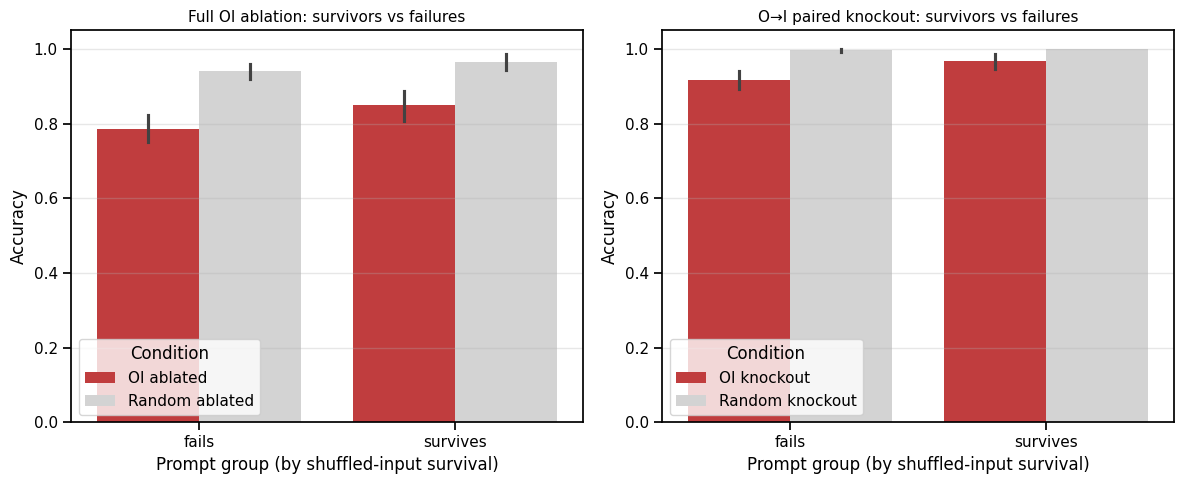


SURVIVES (n=278):
  Full OI abl acc:   0.849
  Full rand abl acc: 0.964
  Specific effect:   +0.115
  O->I OI ko acc:    0.968
  O->I rand ko acc:  1.000
  Specific effect:   +0.032

FAILS (n=515):
  Full OI abl acc:   0.786
  Full rand abl acc: 0.942
  Specific effect:   +0.155
  O->I OI ko acc:    0.917
  O->I rand ko acc:  0.998
  Specific effect:   +0.082


In [16]:
# === Step 4: Plot results ===

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Full OI ablation accuracy by mechanism group
ax = axes[0]
plot_data = []
for _, row in df_bridge.iterrows():
    plot_data.append({'Group': row['mechanism'], 'Condition': 'OI ablated', 'Accuracy': row['acc_full_oi_abl']})
    plot_data.append({'Group': row['mechanism'], 'Condition': 'Random ablated', 'Accuracy': row['acc_full_rand_abl']})
pdf = pd.DataFrame(plot_data)
sns.barplot(data=pdf, x='Group', y='Accuracy', hue='Condition',
            palette={'OI ablated': 'tab:red', 'Random ablated': 'lightgray'},
            errorbar=('ci', 95), ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title('Full OI ablation: survivors vs failures', fontsize=11)
ax.set_xlabel('Prompt group (by shuffled-input survival)')
ax.grid(True, alpha=0.3, axis='y')

# Panel B: O→I paired knockout accuracy by mechanism group
ax = axes[1]
plot_data2 = []
for _, row in df_bridge.iterrows():
    plot_data2.append({'Group': row['mechanism'], 'Condition': 'OI knockout', 'Accuracy': row['acc_oi_knockout']})
    plot_data2.append({'Group': row['mechanism'], 'Condition': 'Random knockout', 'Accuracy': row['acc_rand_knockout']})
pdf2 = pd.DataFrame(plot_data2)
sns.barplot(data=pdf2, x='Group', y='Accuracy', hue='Condition',
            palette={'OI knockout': 'tab:red', 'Random knockout': 'lightgray'},
            errorbar=('ci', 95), ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title('O\u2192I paired knockout: survivors vs failures', fontsize=11)
ax.set_xlabel('Prompt group (by shuffled-input survival)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

# Print summary
for mech in ['survives', 'fails']:
    sub = df_bridge[df_bridge['mechanism'] == mech]
    n = len(sub)
    print(f'\n{mech.upper()} (n={n}):')
    print(f'  Full OI abl acc:   {sub["acc_full_oi_abl"].mean():.3f}')
    print(f'  Full rand abl acc: {sub["acc_full_rand_abl"].mean():.3f}')
    print(f'  Specific effect:   {sub["acc_full_rand_abl"].mean() - sub["acc_full_oi_abl"].mean():+.3f}')
    print(f'  O->I OI ko acc:    {sub["acc_oi_knockout"].mean():.3f}')
    print(f'  O->I rand ko acc:  {sub["acc_rand_knockout"].mean():.3f}')
    print(f'  Specific effect:   {sub["acc_rand_knockout"].mean() - sub["acc_oi_knockout"].mean():+.3f}')

In [17]:
# === Step 5: Per-task breakdown ===

print(f'{"Task":<30s} {"n_surv":>6s} {"n_fail":>6s} {"OI_eff_surv":>11s} {"OI_eff_fail":>11s} {"diff":>8s}')
print('-' * 80)
for task_name in HENDEL_TASKS:
    sub = df_bridge[df_bridge['task'] == task_name]
    surv = sub[sub['mechanism'] == 'survives']
    fail = sub[sub['mechanism'] == 'fails']
    if len(surv) == 0 or len(fail) == 0:
        print(f'{task_name:<30s} {len(surv):>6d} {len(fail):>6d}   (skipped - need both groups)')
        continue
    eff_s = surv['acc_full_rand_abl'].mean() - surv['acc_full_oi_abl'].mean()
    eff_f = fail['acc_full_rand_abl'].mean() - fail['acc_full_oi_abl'].mean()
    print(f'{task_name:<30s} {len(surv):>6d} {len(fail):>6d} {eff_s:>+11.3f} {eff_f:>+11.3f} {eff_f - eff_s:>+8.3f}')

Task                           n_surv n_fail OI_eff_surv OI_eff_fail     diff
--------------------------------------------------------------------------------
knowledge/country_capital           8     29      +0.000      +0.241   +0.241
knowledge/football_player_position     31     10      +0.516      +0.100   -0.416
knowledge/location_continent       37      7      +0.027      +0.714   +0.687
knowledge/location_country          6     27      +0.667      +0.444   -0.222
knowledge/location_language        17     23      +0.118      +0.174   +0.056
knowledge/location_religion        40      7      +0.075      +0.286   +0.211
knowledge/person_language          11     32      +0.000      +0.125   +0.125
knowledge/person_profession        19     13      +0.158      +0.615   +0.457
linguistic/antonyms                14     32      +0.000      +0.094   +0.094
linguistic/plural_singular         11     37      +0.091      +0.243   +0.152
linguistic/present_simple_gerund     16     32      +0.00

---
# VERSION A: Ambiguity continuum

**Design:** Country → Capital with varying fractions of ambiguous demos.

- **Unambiguous demo:** country where capital ≠ largest city (e.g., USA → Washington DC)
- **Ambiguous demo:** country where capital = largest/major city (e.g., Japan → Tokyo)

Vary ambiguous fraction: 0%, 30%, 60%, 90%.

**Measure at each level:**
1. ICL accuracy
2. Patching recovery (task vector quality)
3. OI head attention score

**Prediction:** As ambiguity increases, patching recovery decreases and OI scores increase.

In [18]:
# === Define the ambiguous/unambiguous demo pools ===
#
# Unambiguous: capital != largest city
# Ambiguous: capital = largest/major city (could be capital OR largest city)
#
# We use a curated list. The key: for ambiguous pairs, the output (capital)
# is also what you'd answer for "largest city," so the demo is consistent
# with both tasks.

UNAMBIG_PAIRS = [
    ('USA', 'Washington DC'),
    ('Brazil', 'Brasilia'),
    ('Australia', 'Canberra'),
    ('Canada', 'Ottawa'),
    ('Turkey', 'Ankara'),
    ('India', 'New Delhi'),
    ('Myanmar', 'Naypyidaw'),
    ('Nigeria', 'Abuja'),
    ('South Africa', 'Pretoria'),
    ('Pakistan', 'Islamabad'),
    ('Switzerland', 'Bern'),
    ('Tanzania', 'Dodoma'),
    ('Ivory Coast', 'Yamoussoukro'),
    ('Belize', 'Belmopan'),
]

AMBIG_PAIRS = [
    ('Japan', 'Tokyo'),
    ('France', 'Paris'),
    ('England', 'London'),
    ('South Korea', 'Seoul'),
    ('Egypt', 'Cairo'),
    ('Peru', 'Lima'),
    ('Thailand', 'Bangkok'),
    ('Argentina', 'Buenos Aires'),
    ('Cuba', 'Havana'),
    ('Greece', 'Athens'),
    ('Portugal', 'Lisbon'),
    ('Austria', 'Vienna'),
    ('Denmark', 'Copenhagen'),
    ('Chile', 'Santiago'),
]

# Query pool (unambiguous, held out)
QUERY_POOL = [
    ('China', 'Beijing'),
    ('Italy', 'Rome'),
    ('Germany', 'Berlin'),
    ('Spain', 'Madrid'),
    ('Mexico', 'Mexico City'),
    ('Russia', 'Moscow'),
    ('Poland', 'Warsaw'),
    ('Sweden', 'Stockholm'),
    ('Norway', 'Oslo'),
    ('Finland', 'Helsinki'),
]

# Ambiguity levels: fraction of demos that are ambiguous
AMBIG_FRACS = [0.0, 0.3, 0.6, 0.9]
N_DEMOS_A = 10
N_PROMPTS_A = 50

print(f'{len(UNAMBIG_PAIRS)} unambiguous, {len(AMBIG_PAIRS)} ambiguous, {len(QUERY_POOL)} queries')

14 unambiguous, 14 ambiguous, 10 queries


In [19]:
# === Generate prompts at each ambiguity level ===

ambig_prompts = {}  # frac -> list of pdata

for frac in AMBIG_FRACS:
    n_ambig = int(round(N_DEMOS_A * frac))
    n_unambig = N_DEMOS_A - n_ambig
    prompts = []
    rng = random.Random(hash(f'ambig_{frac}') % 10**6)
    
    for _ in range(N_PROMPTS_A):
        a_demos = rng.sample(AMBIG_PAIRS, min(n_ambig, len(AMBIG_PAIRS)))
        u_demos = rng.sample(UNAMBIG_PAIRS, min(n_unambig, len(UNAMBIG_PAIRS)))
        demo_pairs = a_demos + u_demos
        rng.shuffle(demo_pairs)
        qi, qo = rng.choice(QUERY_POOL)
        prompt = build_icl_prompt(demo_pairs, qi)
        prompts.append({
            'demo_pairs': demo_pairs,
            'query_input': qi,
            'query_output': qo,
            'prompt': prompt,
            'n_ambig': n_ambig,
        })
    ambig_prompts[frac] = prompts
    print(f'  frac={frac:.1f}  n_ambig={n_ambig}  n_unambig={n_unambig}  prompts={len(prompts)}')

  frac=0.0  n_ambig=0  n_unambig=10  prompts=50
  frac=0.3  n_ambig=3  n_unambig=7  prompts=50
  frac=0.6  n_ambig=6  n_unambig=4  prompts=50
  frac=0.9  n_ambig=9  n_unambig=1  prompts=50


In [20]:
# === Measure 1: ICL accuracy at each ambiguity level ===

ambig_icl_acc = {}
for frac in AMBIG_FRACS:
    accs = []
    for pdata in tqdm(ambig_prompts[frac], desc=f'ICL frac={frac:.1f}'):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        accs.append(check_correct(model, tokens, pdata['query_output']))
        torch.cuda.empty_cache()
    ambig_icl_acc[frac] = np.array(accs)
    print(f'  frac={frac:.1f}  ICL acc={np.mean(accs):.3f}')

ICL frac=0.0: 100%|██████████| 50/50 [00:02<00:00, 21.37it/s]


  frac=0.0  ICL acc=1.000


ICL frac=0.3: 100%|██████████| 50/50 [00:02<00:00, 22.72it/s]


  frac=0.3  ICL acc=1.000


ICL frac=0.6: 100%|██████████| 50/50 [00:02<00:00, 21.60it/s]


  frac=0.6  ICL acc=1.000


ICL frac=0.9: 100%|██████████| 50/50 [00:02<00:00, 22.03it/s]

  frac=0.9  ICL acc=1.000


In [21]:
# === Measure 2: Task vector patching at each ambiguity level ===
#
# For each prompt: extract residual at final position from ICL prompt,
# patch into a 0-shot prompt with a DIFFERENT query, check accuracy.
# Sweep across layers.

PATCH_LAYERS = list(range(n_layers))

ambig_patching = {}  # frac -> array of shape (n_prompts, n_layers)

for frac in AMBIG_FRACS:
    patch_accs = []
    for pdata in tqdm(ambig_prompts[frac], desc=f'Patch frac={frac:.1f}'):
        tokens_icl = model.to_tokens(pdata['prompt'], prepend_bos=True)
        
        # Pick a different query for 0-shot
        other_queries = [q for q in QUERY_POOL if q[0] != pdata['query_input']]
        zs_qi, zs_qo = random.choice(other_queries)
        zs_prompt = f'{zs_qi} \u2192'
        tokens_zs = model.to_tokens(zs_prompt, prepend_bos=True)
        
        # Get ICL residuals at all layers
        with torch.no_grad():
            _, cache_icl = model.run_with_cache(tokens_icl,
                names_filter=lambda n: 'resid_post' in n)
        
        layer_accs = []
        for L in PATCH_LAYERS:
            icl_resid = cache_icl['resid_post', L][0, -1].clone()  # final position
            
            def patch_hook(resid, hook, _v=icl_resid):
                resid[0, -1] = _v
                return resid
            
            hooks = [(f'blocks.{L}.hook_resid_post', patch_hook)]
            acc = check_correct(model, tokens_zs, zs_qo, hooks=hooks)
            layer_accs.append(acc)
        
        patch_accs.append(layer_accs)
        del cache_icl; torch.cuda.empty_cache()
    
    ambig_patching[frac] = np.array(patch_accs)
    peak = np.mean(ambig_patching[frac], axis=0).max()
    best_layer = np.mean(ambig_patching[frac], axis=0).argmax()
    print(f'  frac={frac:.1f}  peak patching acc={peak:.3f} at layer {best_layer}')

Patch frac=0.0: 100%|██████████| 50/50 [01:03<00:00,  1.28s/it]


  frac=0.0  peak patching acc=0.880 at layer 12


Patch frac=0.3: 100%|██████████| 50/50 [01:04<00:00,  1.30s/it]


  frac=0.3  peak patching acc=0.900 at layer 12


Patch frac=0.6: 100%|██████████| 50/50 [01:06<00:00,  1.34s/it]


  frac=0.6  peak patching acc=0.820 at layer 12


Patch frac=0.9: 100%|██████████| 50/50 [01:02<00:00,  1.24s/it]

  frac=0.9  peak patching acc=0.940 at layer 12


In [22]:
# === Measure 3: OI head attention score at each ambiguity level ===

ambig_oi_scores = {}
for frac in AMBIG_FRACS:
    sc = score_oi_heads(ambig_prompts[frac], desc=f'OI frac={frac:.1f}')
    # Summarize: mean score of top 10% heads
    flat = sorted(sc.flatten(), reverse=True)
    top_mean = np.mean(flat[:top10pct_n])
    ambig_oi_scores[frac] = {'full_matrix': sc, 'top_mean': top_mean}
    print(f'  frac={frac:.1f}  mean top-{top10pct_n} OI score={top_mean:.4f}')

  frac=0.0  mean top-67 OI score=0.0571


  frac=0.3  mean top-67 OI score=0.0622


  frac=0.6  mean top-67 OI score=0.0688


  frac=0.9  mean top-67 OI score=0.0843


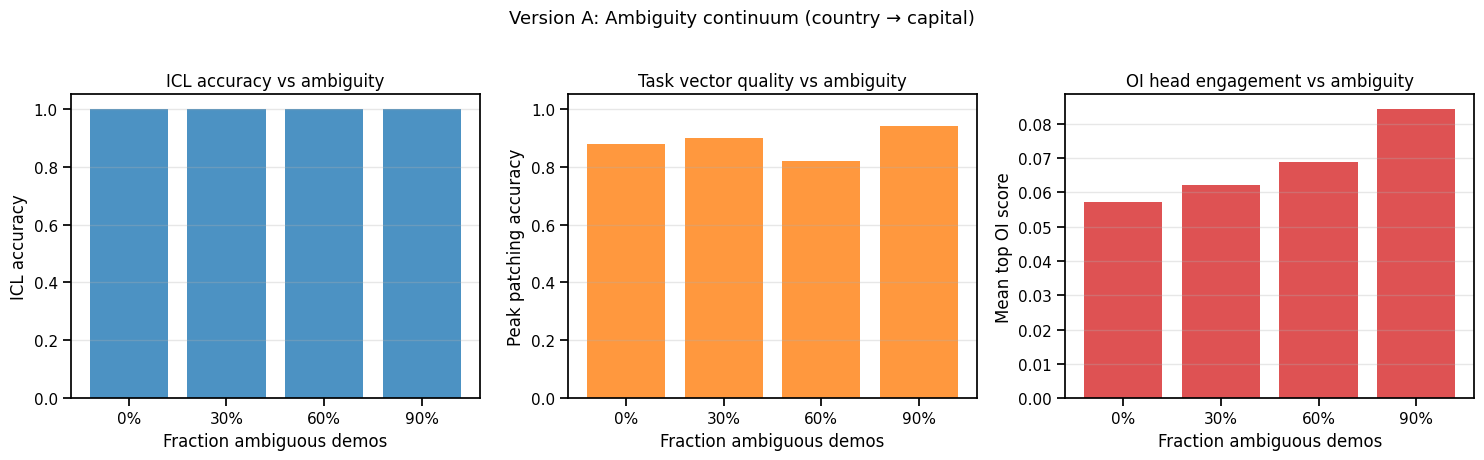

  Frac  ICL acc Peak patch   OI score
--------------------------------------
    0%    1.000      0.880     0.0571
   30%    1.000      0.900     0.0622
   60%    1.000      0.820     0.0688
   90%    1.000      0.940     0.0843


In [23]:
# === Plot Version A results ===

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

fracs = sorted(AMBIG_FRACS)

# Panel 1: ICL accuracy
ax = axes[0]
means = [ambig_icl_acc[f].mean() for f in fracs]
sems = [ambig_icl_acc[f].std() / np.sqrt(len(ambig_icl_acc[f])) for f in fracs]
ax.bar([f'{f:.0%}' for f in fracs], means, yerr=sems, color='tab:blue', alpha=0.8)
ax.set_ylim(0, 1.05)
ax.set_xlabel('Fraction ambiguous demos')
ax.set_ylabel('ICL accuracy')
ax.set_title('ICL accuracy vs ambiguity')
ax.grid(True, alpha=0.3, axis='y')

# Panel 2: Peak patching recovery
ax = axes[1]
peaks = [np.mean(ambig_patching[f], axis=0).max() for f in fracs]
ax.bar([f'{f:.0%}' for f in fracs], peaks, color='tab:orange', alpha=0.8)
ax.set_ylim(0, 1.05)
ax.set_xlabel('Fraction ambiguous demos')
ax.set_ylabel('Peak patching accuracy')
ax.set_title('Task vector quality vs ambiguity')
ax.grid(True, alpha=0.3, axis='y')

# Panel 3: OI head engagement
ax = axes[2]
oi_means = [ambig_oi_scores[f]['top_mean'] for f in fracs]
ax.bar([f'{f:.0%}' for f in fracs], oi_means, color='tab:red', alpha=0.8)
ax.set_xlabel('Fraction ambiguous demos')
ax.set_ylabel('Mean top OI score')
ax.set_title('OI head engagement vs ambiguity')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Version A: Ambiguity continuum (country \u2192 capital)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# Summary table
print(f'{"Frac":>6s} {"ICL acc":>8s} {"Peak patch":>10s} {"OI score":>10s}')
print('-' * 38)
for f in fracs:
    print(f'{f:>6.0%} {ambig_icl_acc[f].mean():>8.3f} {np.mean(ambig_patching[f], axis=0).max():>10.3f} '
          f'{ambig_oi_scores[f]["top_mean"]:>10.4f}')

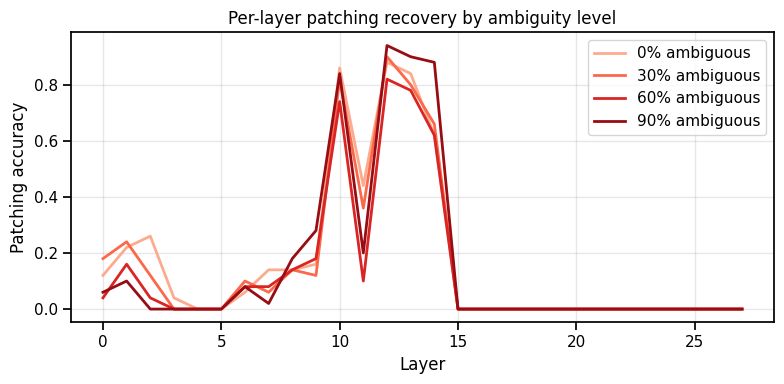

In [24]:
# === Patching curves per ambiguity level ===

fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(fracs)))
for f, c in zip(fracs, colors):
    mean_curve = np.mean(ambig_patching[f], axis=0)
    ax.plot(PATCH_LAYERS, mean_curve, label=f'{f:.0%} ambiguous', color=c, lw=2)
ax.set_xlabel('Layer')
ax.set_ylabel('Patching accuracy')
ax.set_title('Per-layer patching recovery by ambiguity level')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [25]:
# === Patching experiment split by survive/fail ===
# Uses hendel_classification from §b3

PATCH_LAYERS = list(range(n_layers))
N_PER_GROUP = 5  # quick test

patch_results = []  # list of dicts

for task_name in HENDEL_TASKS:
    surv = [r for r in hendel_classification[task_name] if r['orig_correct'] and r['shuffle_correct']]
    fail = [r for r in hendel_classification[task_name] if r['orig_correct'] and not r['shuffle_correct']]
    
    for group_name, group in [('survives', surv), ('fails', fail)]:
        for r in group[:N_PER_GROUP]:
            pdata = r['pdata']
            tokens_icl = model.to_tokens(pdata['prompt'], prepend_bos=True)
            
            # Pick a different query for 0-shot
            zs_qi = pdata['query_input'] + ' →'
            # Actually: use a prompt from same task with different query
            other = [r2 for r2 in hendel_classification[task_name] 
                     if r2['pdata']['query_input'] != pdata['query_input']]
            if not other:
                continue
            zs_pdata = other[0]['pdata']
            zs_prompt = f"{zs_pdata['query_input']} →"
            zs_answer = zs_pdata['query_output']
            tokens_zs = model.to_tokens(zs_prompt, prepend_bos=True)
            
            # Cache ICL residuals
            with torch.no_grad():
                _, cache_icl = model.run_with_cache(tokens_icl,
                    names_filter=lambda n: 'resid_post' in n)
            
            layer_accs = []
            for L in PATCH_LAYERS:
                icl_resid = cache_icl['resid_post', L][0, -1].clone()
                
                def patch_hook(resid, hook, _v=icl_resid):
                    resid[0, -1] = _v
                    return resid
                
                hooks = [(f'blocks.{L}.hook_resid_post', patch_hook)]
                acc = check_correct(model, tokens_zs, zs_answer, hooks=hooks)
                layer_accs.append(acc)
            
            patch_results.append({
                'task': task_name,
                'group': group_name,
                'layer_accs': layer_accs,
                'peak': max(layer_accs),
            })
            del cache_icl; torch.cuda.empty_cache()
    
    n_s = sum(1 for p in patch_results if p['task'] == task_name and p['group'] == 'survives')
    n_f = sum(1 for p in patch_results if p['task'] == task_name and p['group'] == 'fails')
    print(f'{task_name:<45s} survives={n_s} fails={n_f}')

# === Plot ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: peak patching by group
ax = axes[0]
df_patch = pd.DataFrame(patch_results)
sns.barplot(data=df_patch, x='group', y='peak', 
            palette={'survives': 'tab:blue', 'fails': 'tab:red'},
            errorbar=('ci', 95), ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title('Peak patching accuracy by group')
ax.set_ylabel('Peak patching accuracy')
ax.grid(True, alpha=0.3, axis='y')

# Panel 2: per-layer curves
ax = axes[1]
for grp, color in [('survives', 'tab:blue'), ('fails', 'tab:red')]:
    sub = [p for p in patch_results if p['group'] == grp]
    if not sub:
        continue
    curves = np.array([p['layer_accs'] for p in sub])
    mean_curve = curves.mean(axis=0)
    ax.plot(PATCH_LAYERS, mean_curve, label=grp, color=color, lw=2)
ax.set_xlabel('Layer')
ax.set_ylabel('Patching accuracy')
ax.set_title('Per-layer patching: survives vs fails')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Summary
for grp in ['survives', 'fails']:
    sub = [p for p in patch_results if p['group'] == grp]
    peaks = [p['peak'] for p in sub]
    print(f'{grp}: n={len(sub)}  mean peak={np.mean(peaks):.3f}')

knowledge/country_capital                     survives=5 fails=5


KeyboardInterrupt: 

In [26]:
# === Compensation experiment: 2x2 ablation (FV heads x OI heads) ===
#
# Step 1: Score "output-attending" heads on Hendel tasks
#   These attend from final position to output positions (the FV/task-vector pathway)
# Step 2: 2x2 ablation on Hendel prompts that the model gets correct
#   {FV intact, FV ablated} x {OI intact, OI ablated}
# Prediction: OI ablation effect is LARGER when FV heads are already ablated

# === Step 1: Score output-attending (OA) heads ===
# Score = mean attention from final position to output positions, baseline-subtracted

def score_oa_heads(prompts_data, desc='OA Scoring'):
    """Heads attending from final position to output positions."""
    num_sum  = np.zeros((n_layers, n_heads), dtype=np.float64)
    base_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
    cnt = 0
    for pdata in tqdm(prompts_data, desc=desc, leave=False):
        demos = pdata['demo_pairs']
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        seq_len = tokens.shape[1]
        per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
        all_out = set()
        all_in = set()
        for d in per_demo:
            for p in d.get('output_positions', []): all_out.add(p)
            for p in d.get('input_positions', []):  all_in.add(p)
        final_pos = seq_len - 1
        if not all_out:
            continue
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
        for L in range(n_layers):
            patt = cache['pattern', L][0].cpu().float()  # (n_heads, seq, seq)
            # Numerator: final -> outputs
            for o in all_out:
                num_sum[L, :] += patt[:, final_pos, o].numpy()
            # Baseline: final -> all non-output positions (excluding BOS)
            non_out = [p for p in range(1, seq_len) if p not in all_out and p != final_pos]
            for p in non_out:
                base_sum[L, :] += patt[:, final_pos, p].numpy()
        n_out = len(all_out)
        n_non = len([p for p in range(1, seq_len) if p not in all_out and p != final_pos])
        if n_out > 0:
            num_sum_norm = num_sum / n_out
        if n_non > 0:
            base_sum_norm = base_sum / n_non
        cnt += 1
        del cache; torch.cuda.empty_cache()
    # Simple: just return average attention to outputs at final position
    return num_sum / max(cnt, 1)

print('Scoring OA (output-attending) heads on Hendel tasks...')
rng_oa = random.Random(123)
oa_sample = rng_oa.sample(all_hendel_prompts, min(100, len(all_hendel_prompts)))
hendel_oa_scores = score_oa_heads(oa_sample, desc='Hendel OA')

# Select top 10% OA heads
flat_oa = sorted([(L, h, hendel_oa_scores[L, h]) 
                   for L in range(n_layers) for h in range(n_heads)],
                  key=lambda x: -x[2])
hendel_oa_top = [(L, h) for L, h, _ in flat_oa[:top10pct_n]]
print(f'Top {top10pct_n} OA heads selected')
print('Top 10:', [(L, h, f'{s:.3f}') for L, h, s in flat_oa[:10]])

# Check overlap with OI heads
oi_set = set(hendel_oi_top)
oa_set = set(hendel_oa_top)
overlap = oi_set & oa_set
print(f'\nOI heads: {len(oi_set)}, OA heads: {len(oa_set)}, overlap: {len(overlap)}')
print(f'Jaccard: {len(overlap) / len(oi_set | oa_set):.3f}')

Scoring OA (output-attending) heads on Hendel tasks...


Top 67 OA heads selected
Top 10: [(12, 20, '0.920'), (8, 2, '0.703'), (14, 12, '0.629'), (10, 22, '0.619'), (14, 1, '0.608'), (10, 3, '0.582'), (6, 1, '0.567'), (14, 22, '0.536'), (17, 0, '0.522'), (12, 23, '0.492')]

OI heads: 67, OA heads: 67, overlap: 7
Jaccard: 0.055


In [29]:
# === Step 2: 2x2 ablation ===
# 
# Four conditions:
#   (1) Neither ablated (baseline)
#   (2) OI only ablated
#   (3) OA only ablated (FV pathway disabled)
#   (4) Both ablated
#
# Run on all correct Hendel prompts, 5 per task

N_PER_TASK = 50

oi_abl_hooks = make_ablation_hooks(heads_by_layer(hendel_oi_top))
oa_abl_hooks = make_ablation_hooks(heads_by_layer(hendel_oa_top))

# Combined ablation hooks: need to merge both into one set
combined_heads = list(set(hendel_oi_top + hendel_oa_top))
both_abl_hooks = make_ablation_hooks(heads_by_layer(combined_heads))

comp_results = []

for task_name in HENDEL_TASKS:
    correct_prompts = [r['pdata'] for r in hendel_classification[task_name] if r['orig_correct']]
    
    for pdata in tqdm(correct_prompts[:N_PER_TASK], desc=f'{task_name} 2x2'):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        ans = pdata['query_output']
        
        # (1) Baseline — neither ablated
        acc_none = check_correct(model, tokens, ans)
        
        # (2) OI only ablated
        acc_oi = check_correct(model, tokens, ans, hooks=oi_abl_hooks)
        
        # (3) OA only ablated
        acc_oa = check_correct(model, tokens, ans, hooks=oa_abl_hooks)
        
        # (4) Both ablated
        acc_both = check_correct(model, tokens, ans, hooks=both_abl_hooks)
        
        comp_results.append({
            'task': task_name,
            'acc_none': acc_none,
            'acc_oi_only': acc_oi,
            'acc_oa_only': acc_oa,
            'acc_both': acc_both,
        })
        torch.cuda.empty_cache()

df_comp = pd.DataFrame(comp_results)
print(f'{len(df_comp)} prompts total')

translation/it_en 2x2: 100%|██████████| 38/38 [00:08<00:00,  4.39it/s]

793 prompts total


=== 2x2 Ablation Results ===
                    OI intact    OI ablated   OI effect
  OA intact         1.000        0.808        +0.192
  OA ablated        0.090        0.015        +0.074
  OA effect         +0.910        +0.793

OI effect when OA intact:   +0.192
OI effect when OA ablated:  +0.074
INTERACTION (key number):   -0.117

>>> OI heads do NOT matter more when OA heads are disabled.
    The two circuits may be independent rather than compensatory.


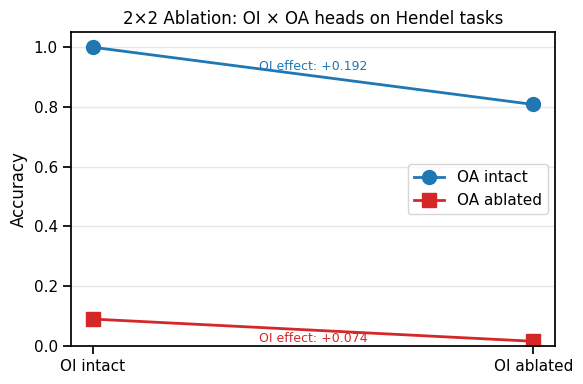

In [30]:
# === Step 3: Analyze the 2x2 ===

A = df_comp['acc_none'].mean()          # F(0,0): nothing ablated
B = df_comp['acc_oi_only'].mean()       # F(1,0): OI ablated
C = df_comp['acc_oa_only'].mean()       # F(0,1): OA ablated  
D = df_comp['acc_both'].mean()          # F(1,1): both ablated

print('=== 2x2 Ablation Results ===')
print(f'                    OI intact    OI ablated   OI effect')
print(f'  OA intact         {A:.3f}        {B:.3f}        {A - B:+.3f}')
print(f'  OA ablated        {C:.3f}        {D:.3f}        {C - D:+.3f}')
print(f'  OA effect         {A - C:+.3f}        {B - D:+.3f}')
print()
print(f'OI effect when OA intact:   {A - B:+.3f}')
print(f'OI effect when OA ablated:  {C - D:+.3f}')
print(f'INTERACTION (key number):   {(C - D) - (A - B):+.3f}')
print()
if (C - D) > (A - B):
    print('>>> OI heads matter MORE when OA heads are disabled.')
    print('    This supports compensation: pairing heads pick up slack')
    print('    when the task-vector pathway is blocked.')
else:
    print('>>> OI heads do NOT matter more when OA heads are disabled.')
    print('    The two circuits may be independent rather than compensatory.')

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
x = [0, 1]
ax.plot(x, [A, B], 'o-', color='tab:blue', lw=2, ms=10, label='OA intact')
ax.plot(x, [C, D], 's-', color='tab:red', lw=2, ms=10, label='OA ablated')
ax.set_xticks(x)
ax.set_xticklabels(['OI intact', 'OI ablated'])
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('2×2 Ablation: OI × OA heads on Hendel tasks')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Annotate interaction
ax.annotate(f'OI effect: {A-B:+.3f}', xy=(0.5, (A+B)/2 + 0.02), ha='center', color='tab:blue', fontsize=9)
ax.annotate(f'OI effect: {C-D:+.3f}', xy=(0.5, (C+D)/2 - 0.04), ha='center', color='tab:red', fontsize=9)

plt.tight_layout(); plt.show()

In [31]:
# === Graded compensation: ablate increasing fractions of OA heads ===
#
# At each OA degradation level (0%, 25%, 50%, 75%, 100% of top OA heads):
#   Measure accuracy with and without OI ablation
#   The OI effect at each level tells us whether pairing heads
#   become more important as the task-vector pathway weakens
#
# Prediction: OI effect increases with OA degradation (before floor)

# Sort OA heads by score (strongest first)
oa_ranked = [(L, h) for L, h, _ in flat_oa[:top10pct_n]]
OA_FRACS = [0.0, 0.25, 0.50, 0.75, 1.0]
N_PER_TASK_G = 5

oi_abl_hooks = make_ablation_hooks(heads_by_layer(hendel_oi_top))

graded_results = []

for oa_frac in OA_FRACS:
    n_oa_ablate = int(round(len(oa_ranked) * oa_frac))
    oa_subset = oa_ranked[:n_oa_ablate]
    
    if oa_subset:
        oa_sub_hooks = make_ablation_hooks(heads_by_layer(oa_subset))
        combined = list(set(oa_subset + hendel_oi_top))
        both_hooks = make_ablation_hooks(heads_by_layer(combined))
    else:
        oa_sub_hooks = []
        both_hooks = oi_abl_hooks
    
    for task_name in HENDEL_TASKS:
        correct_prompts = [r['pdata'] for r in hendel_classification[task_name] if r['orig_correct']]
        
        for pdata in correct_prompts[:N_PER_TASK_G]:
            tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
            ans = pdata['query_output']
            
            # OA degraded, OI intact
            if oa_sub_hooks:
                acc_oi_intact = check_correct(model, tokens, ans, hooks=oa_sub_hooks)
            else:
                acc_oi_intact = check_correct(model, tokens, ans)
            
            # OA degraded, OI ablated
            acc_oi_ablated = check_correct(model, tokens, ans, hooks=both_hooks)
            
            graded_results.append({
                'task': task_name,
                'oa_frac': oa_frac,
                'n_oa_ablated': n_oa_ablate,
                'acc_oi_intact': acc_oi_intact,
                'acc_oi_ablated': acc_oi_ablated,
            })
            torch.cuda.empty_cache()
    
    sub = [r for r in graded_results if r['oa_frac'] == oa_frac]
    intact = np.mean([r['acc_oi_intact'] for r in sub])
    ablated = np.mean([r['acc_oi_ablated'] for r in sub])
    print(f'OA frac={oa_frac:.0%} ({n_oa_ablate} heads)  '
          f'OI intact={intact:.3f}  OI ablated={ablated:.3f}  '
          f'OI effect={intact - ablated:+.3f}')

df_graded = pd.DataFrame(graded_results)

OA frac=0% (0 heads)  OI intact=1.000  OI ablated=0.810  OI effect=+0.190
OA frac=25% (17 heads)  OI intact=0.790  OI ablated=0.200  OI effect=+0.590
OA frac=50% (34 heads)  OI intact=0.240  OI ablated=0.010  OI effect=+0.230
OA frac=75% (50 heads)  OI intact=0.120  OI ablated=0.000  OI effect=+0.120
OA frac=100% (67 heads)  OI intact=0.080  OI ablated=0.000  OI effect=+0.080


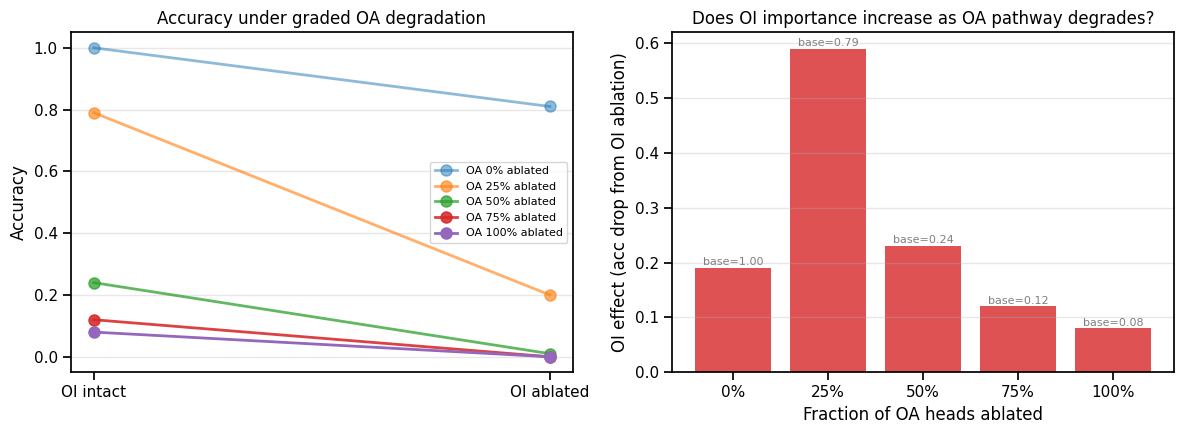

 OA frac n_heads  Baseline OI ablated  OI effect
------------------------------------------------
     0%       0     1.000      0.810     +0.190
    25%      17     0.790      0.200     +0.590
    50%      34     0.240      0.010     +0.230
    75%      50     0.120      0.000     +0.120
   100%      67     0.080      0.000     +0.080


In [32]:
# === Plot graded compensation ===

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: accuracy curves
ax = axes[0]
for oa_frac in OA_FRACS:
    sub = df_graded[df_graded['oa_frac'] == oa_frac]
    intact = sub['acc_oi_intact'].mean()
    ablated = sub['acc_oi_ablated'].mean()
    ax.plot([0, 1], [intact, ablated], 'o-', lw=2, ms=8,
            label=f'OA {oa_frac:.0%} ablated',
            alpha=0.5 + 0.5 * oa_frac)
ax.set_xticks([0, 1])
ax.set_xticklabels(['OI intact', 'OI ablated'])
ax.set_ylabel('Accuracy')
ax.set_ylim(-0.05, 1.05)
ax.set_title('Accuracy under graded OA degradation')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Panel 2: OI effect as a function of OA degradation
ax = axes[1]
oa_fracs_plot = []
oi_effects = []
baselines = []
for oa_frac in OA_FRACS:
    sub = df_graded[df_graded['oa_frac'] == oa_frac]
    intact = sub['acc_oi_intact'].mean()
    ablated = sub['acc_oi_ablated'].mean()
    oi_effects.append(intact - ablated)
    baselines.append(intact)
    oa_fracs_plot.append(oa_frac)

ax.bar([f'{f:.0%}' for f in oa_fracs_plot], oi_effects, color='tab:red', alpha=0.8)
ax.set_xlabel('Fraction of OA heads ablated')
ax.set_ylabel('OI effect (acc drop from OI ablation)')
ax.set_title('Does OI importance increase as OA pathway degrades?')
ax.grid(True, alpha=0.3, axis='y')

# Add baseline accuracy as text
for i, (f, b, e) in enumerate(zip(oa_fracs_plot, baselines, oi_effects)):
    ax.text(i, e + 0.005, f'base={b:.2f}', ha='center', fontsize=8, color='gray')

plt.tight_layout(); plt.show()

# Summary table
print(f'{"OA frac":>8s} {"n_heads":>7s} {"Baseline":>9s} {"OI ablated":>10s} {"OI effect":>10s}')
print('-' * 48)
for oa_frac in OA_FRACS:
    sub = df_graded[df_graded['oa_frac'] == oa_frac]
    intact = sub['acc_oi_intact'].mean()
    ablated = sub['acc_oi_ablated'].mean()
    n = int(round(len(oa_ranked) * oa_frac))
    print(f'{oa_frac:>7.0%} {n:>7d} {intact:>9.3f} {ablated:>10.3f} {intact - ablated:>+10.3f}')

repetition          none=1.00  OA_abl=0.00  OI_abl=0.50
prepend_first       none=1.00  OA_abl=0.00  OI_abl=0.40
append_last         none=1.00  OA_abl=0.00  OI_abl=0.20
drop_first          none=1.00  OA_abl=0.00  OI_abl=0.00
drop_last           none=1.00  OA_abl=0.20  OI_abl=0.30
reverse             none=1.00  OA_abl=0.00  OI_abl=0.00
swap_ends           none=1.00  OA_abl=0.40  OI_abl=0.10
rotate_left         none=1.00  OA_abl=0.00  OI_abl=0.00
suffix_ed           none=1.00  OA_abl=0.00  OI_abl=0.60
double_vowels       none=1.00  OA_abl=0.00  OI_abl=0.00

=== Nonce tasks aggregate ===
  Unablated:    1.000
  OA ablated:   0.060
  OI ablated:   0.210

>>> OA ablation devastates nonce tasks.
    Supports SERIAL: OI feeds through OA to final position.


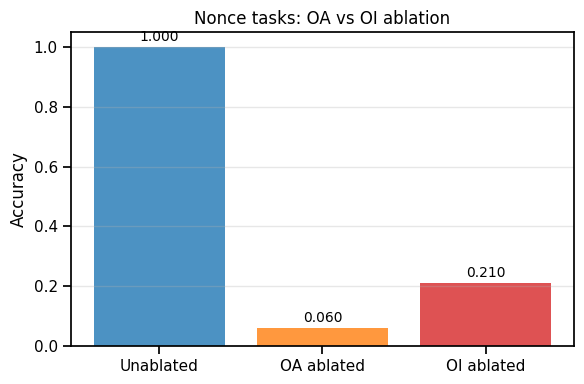

In [33]:
# === Serial vs Parallel: ablate OA heads on nonce tasks ===
#
# If serial (OI → outputs → OA → final): OA ablation kills nonce accuracy
# If parallel (OI has own path): OA ablation doesn't matter for nonce
#
# Uses OA heads scored on Hendel tasks (hendel_oa_top)
# Uses filtered_prompts.pkl nonce tasks

import os, pickle
SAVE_PATH = 'filtered_prompts.pkl'
with open(SAVE_PATH, 'rb') as f:
    saved = pickle.load(f)
TASKS_NONCE = saved['TASKS']
TASK_NAMES_NONCE = saved['TASK_NAMES_ACTIVE']
NONCE_ONLY = [n for n in TASK_NAMES_NONCE if n in [
    'repetition', 'prepend_first', 'append_last', 'drop_first',
    'drop_last', 'reverse', 'swap_ends', 'rotate_left',
    'suffix_ed', 'double_vowels']]

oa_abl_hooks = make_ablation_hooks(heads_by_layer(hendel_oa_top))
oi_abl_hooks = make_ablation_hooks(heads_by_layer(hendel_oi_top))

N_PER = 10

serial_results = []

for name in NONCE_ONLY:
    for pdata in TASKS_NONCE[name][:N_PER]:
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        ans = pdata['query_output']
        
        acc_none = check_correct(model, tokens, ans)
        acc_oa_abl = check_correct(model, tokens, ans, hooks=oa_abl_hooks)
        acc_oi_abl = check_correct(model, tokens, ans, hooks=oi_abl_hooks)
        
        serial_results.append({
            'task': name,
            'acc_none': acc_none,
            'acc_oa_ablated': acc_oa_abl,
            'acc_oi_ablated': acc_oi_abl,
        })
        torch.cuda.empty_cache()
    
    sub = [r for r in serial_results if r['task'] == name]
    print(f'{name:<18s}  none={np.mean([r["acc_none"] for r in sub]):.2f}  '
          f'OA_abl={np.mean([r["acc_oa_ablated"] for r in sub]):.2f}  '
          f'OI_abl={np.mean([r["acc_oi_ablated"] for r in sub]):.2f}')

df_serial = pd.DataFrame(serial_results)

# Summary
print(f'\n=== Nonce tasks aggregate ===')
print(f'  Unablated:    {df_serial["acc_none"].mean():.3f}')
print(f'  OA ablated:   {df_serial["acc_oa_ablated"].mean():.3f}')
print(f'  OI ablated:   {df_serial["acc_oi_ablated"].mean():.3f}')
print()
if df_serial['acc_oa_ablated'].mean() < 0.3:
    print('>>> OA ablation devastates nonce tasks.')
    print('    Supports SERIAL: OI feeds through OA to final position.')
elif df_serial['acc_oa_ablated'].mean() > 0.7:
    print('>>> OA ablation barely matters for nonce tasks.')
    print('    Supports PARALLEL: OI has its own path bypassing OA.')
else:
    print('>>> OA ablation partially hurts nonce tasks.')
    print('    Mixed: possibly partially serial, partially parallel.')

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
conditions = ['Unablated', 'OA ablated', 'OI ablated']
means = [df_serial['acc_none'].mean(), 
         df_serial['acc_oa_ablated'].mean(), 
         df_serial['acc_oi_ablated'].mean()]
colors = ['tab:blue', 'tab:orange', 'tab:red']
ax.bar(conditions, means, color=colors, alpha=0.8)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Nonce tasks: OA vs OI ablation')
ax.grid(True, alpha=0.3, axis='y')
for i, m in enumerate(means):
    ax.text(i, m + 0.02, f'{m:.3f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

In [35]:
# === Does OI ablation weaken the task vector? ===
#
# For each Hendel prompt:
#   (a) Extract task vector from normal forward pass
#   (b) Extract task vector with OI heads ablated
#   (c) Extract task vector with random heads ablated (control)
#   (d) Patch each into zero-shot prompt, measure patching accuracy
#
# Split by survive/fail.

PATCH_LAYERS_TV = list(range(n_layers))
N_PER_TASK_TV = 5

oi_abl_hooks_tv = make_ablation_hooks(heads_by_layer(hendel_oi_top))

# Random control: same number of heads, no overlap with OI
oi_set_tv = set(hendel_oi_top)
rng_tv = random.Random(777)
rand_heads_tv = rng_tv.sample([p for p in all_pairs if p not in oi_set_tv], top10pct_n)
rand_abl_hooks_tv = make_ablation_hooks(heads_by_layer(rand_heads_tv))

tv_results = []

for task_name in HENDEL_TASKS:
    classified = hendel_classification[task_name]
    correct = [r for r in classified if r['orig_correct']]
    
    for r in correct[:N_PER_TASK_TV]:
        pdata = r['pdata']
        group = 'survives' if r['shuffle_correct'] else 'fails'
        tokens_icl = model.to_tokens(pdata['prompt'], prepend_bos=True)
        
        # Pick a different query for zero-shot
        other = [r2 for r2 in classified if r2['pdata']['query_input'] != pdata['query_input']]
        if not other:
            continue
        zs_pdata = other[0]['pdata']
        zs_prompt = f"{zs_pdata['query_input']} \u2192"
        zs_answer = zs_pdata['query_output']
        tokens_zs = model.to_tokens(zs_prompt, prepend_bos=True)
        
        # Extract residuals under three conditions
        with torch.no_grad():
            _, cache_normal = model.run_with_cache(tokens_icl,
                names_filter=lambda n: 'resid_post' in n)
        
        with torch.no_grad():
            with model.hooks(fwd_hooks=oi_abl_hooks_tv):
                _, cache_oi_abl = model.run_with_cache(tokens_icl,
                    names_filter=lambda n: 'resid_post' in n)
        
        with torch.no_grad():
            with model.hooks(fwd_hooks=rand_abl_hooks_tv):
                _, cache_rand_abl = model.run_with_cache(tokens_icl,
                    names_filter=lambda n: 'resid_post' in n)
        
        normal_accs = []
        oi_abl_accs = []
        rand_abl_accs = []
        
        for L in PATCH_LAYERS_TV:
            normal_resid = cache_normal['resid_post', L][0, -1].clone()
            oi_resid = cache_oi_abl['resid_post', L][0, -1].clone()
            rand_resid = cache_rand_abl['resid_post', L][0, -1].clone()
            
            def make_patch(vec):
                def hook(resid, hook, _v=vec):
                    resid[0, -1] = _v
                    return resid
                return hook
            
            normal_accs.append(check_correct(model, tokens_zs, zs_answer,
                hooks=[(f'blocks.{L}.hook_resid_post', make_patch(normal_resid))]))
            oi_abl_accs.append(check_correct(model, tokens_zs, zs_answer,
                hooks=[(f'blocks.{L}.hook_resid_post', make_patch(oi_resid))]))
            rand_abl_accs.append(check_correct(model, tokens_zs, zs_answer,
                hooks=[(f'blocks.{L}.hook_resid_post', make_patch(rand_resid))]))
        
        tv_results.append({
            'task': task_name,
            'group': group,
            'normal_peak': max(normal_accs),
            'oi_abl_peak': max(oi_abl_accs),
            'rand_abl_peak': max(rand_abl_accs),
            'normal_curve': normal_accs,
            'oi_abl_curve': oi_abl_accs,
            'rand_abl_curve': rand_abl_accs,
        })
        
        del cache_normal, cache_oi_abl, cache_rand_abl
        torch.cuda.empty_cache()
    
    sub = [r for r in tv_results if r['task'] == task_name]
    print(f'{task_name:<45s} normal={np.mean([r["normal_peak"] for r in sub]):.2f}  '
          f'OI_abl={np.mean([r["oi_abl_peak"] for r in sub]):.2f}  '
          f'rand_abl={np.mean([r["rand_abl_peak"] for r in sub]):.2f}')

df_tv = pd.DataFrame(tv_results)

knowledge/country_capital                     normal=1.00  OI_abl=1.00  rand_abl=1.00
knowledge/football_player_position            normal=0.80  OI_abl=0.60  rand_abl=0.80
knowledge/location_continent                  normal=1.00  OI_abl=1.00  rand_abl=1.00
knowledge/location_country                    normal=0.80  OI_abl=0.60  rand_abl=0.80
knowledge/location_language                   normal=1.00  OI_abl=0.80  rand_abl=0.20
knowledge/location_religion                   normal=0.40  OI_abl=0.40  rand_abl=0.60


KeyboardInterrupt: 

In [ ]:
# === Plot ===

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: peak patching by group
ax = axes[0]
plot_rows = []
for _, row in df_tv.iterrows():
    plot_rows.append({'Group': row['group'], 'Condition': 'Normal', 'Peak': row['normal_peak']})
    plot_rows.append({'Group': row['group'], 'Condition': 'OI ablated', 'Peak': row['oi_abl_peak']})
    plot_rows.append({'Group': row['group'], 'Condition': 'Random ablated', 'Peak': row['rand_abl_peak']})
pdf = pd.DataFrame(plot_rows)
sns.barplot(data=pdf, x='Group', y='Peak', hue='Condition',
            palette={'Normal': 'tab:blue', 'OI ablated': 'tab:red', 'Random ablated': 'lightgray'},
            errorbar=('ci', 95), ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title('Task vector quality under head ablation')
ax.set_ylabel('Peak patching accuracy')
ax.grid(True, alpha=0.3, axis='y')

# Panel 2: per-layer curves, survives
ax = axes[1]
sub = [r for r in tv_results if r['group'] == 'survives']
if sub:
    ax.plot(PATCH_LAYERS_TV, np.array([r['normal_curve'] for r in sub]).mean(axis=0),
            color='tab:blue', lw=2, label='Normal')
    ax.plot(PATCH_LAYERS_TV, np.array([r['oi_abl_curve'] for r in sub]).mean(axis=0),
            color='tab:red', lw=2, ls='--', label='OI ablated')
    ax.plot(PATCH_LAYERS_TV, np.array([r['rand_abl_curve'] for r in sub]).mean(axis=0),
            color='gray', lw=2, ls=':', label='Random ablated')
ax.set_xlabel('Layer')
ax.set_ylabel('Patching accuracy')
ax.set_title('Survives: patching curves')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 3: per-layer curves, fails
ax = axes[2]
sub = [r for r in tv_results if r['group'] == 'fails']
if sub:
    ax.plot(PATCH_LAYERS_TV, np.array([r['normal_curve'] for r in sub]).mean(axis=0),
            color='tab:blue', lw=2, label='Normal')
    ax.plot(PATCH_LAYERS_TV, np.array([r['oi_abl_curve'] for r in sub]).mean(axis=0),
            color='tab:red', lw=2, ls='--', label='OI ablated')
    ax.plot(PATCH_LAYERS_TV, np.array([r['rand_abl_curve'] for r in sub]).mean(axis=0),
            color='gray', lw=2, ls=':', label='Random ablated')
ax.set_xlabel('Layer')
ax.set_ylabel('Patching accuracy')
ax.set_title('Fails: patching curves')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Summary
print(f'\n{"Group":<12s} {"n":>4s} {"Normal":>8s} {"OI abl":>8s} {"Rand abl":>9s} '
      f'{"OI spec":>8s}')
print('-' * 55)
for grp in ['survives', 'fails']:
    sub = df_tv[df_tv['group'] == grp]
    if len(sub) == 0: continue
    nm = sub['normal_peak'].mean()
    oi = sub['oi_abl_peak'].mean()
    rd = sub['rand_abl_peak'].mean()
    spec = rd - oi  # specific effect: random - OI
    print(f'{grp:<12s} {len(sub):>4d} {nm:>8.3f} {oi:>8.3f} {rd:>9.3f} {spec:>+8.3f}')

In [40]:
# === Does amplifying pairing heads weaken the task vector? ===

PATCH_LAYERS_AMP = list(range(n_layers))
N_PER_TASK_AMP = 5

def make_amplify_hooks(head_list, scale):
    hbl = defaultdict(list)
    for L, h in head_list: hbl[L].append(h)
    hooks = []
    for L, h_list in hbl.items():
        def hook(z, hook, _hl=h_list, _s=scale):
            for h in _hl:
                z[0, :, h, :] *= _s
            return z
        hooks.append((f'blocks.{L}.attn.hook_z', hook))
    return hooks

@torch.no_grad()
def check_first_token(model, tokens, expected, hooks=None):
    target_toks = model.to_tokens(' ' + expected.strip(), prepend_bos=False)[0]
    space_id = model.to_tokens(' ', prepend_bos=False)[0, 0].item()
    target_id = None
    for t in target_toks:
        if t.item() != space_id:
            target_id = t.item()
            break
    if target_id is None:
        target_id = target_toks[-1].item()
    if hooks:
        logits = model.run_with_hooks(tokens, fwd_hooks=hooks)[0, -1]
    else:
        logits = model(tokens)[0, -1]
    return int(logits.argmax().item() == target_id)

oi_set_amp = set(hendel_oi_top)
rng_amp = random.Random(888)
rand_heads_amp = rng_amp.sample([p for p in all_pairs if p not in oi_set_amp], top10pct_n)

CONDITIONS = [
    ('normal', []),
    ('oi_2x', make_amplify_hooks(hendel_oi_top, 2.0)),
    ('oi_3x', make_amplify_hooks(hendel_oi_top, 3.0)),
    ('rand_2x', make_amplify_hooks(rand_heads_amp, 2.0)),
    ('rand_3x', make_amplify_hooks(rand_heads_amp, 3.0)),
]

amp_results = []

for task_name in tqdm(HENDEL_TASKS, desc='Tasks'):
    classified = hendel_classification[task_name]
    correct = [r for r in classified if r['orig_correct']]
    
    for r in tqdm(correct[:N_PER_TASK_AMP], desc=f'{task_name}', leave=False):
        pdata = r['pdata']
        group = 'survives' if r['shuffle_correct'] else 'fails'
        tokens_icl = model.to_tokens(pdata['prompt'], prepend_bos=True)
        ans = pdata['query_output']
        
        other = [r2 for r2 in classified if r2['pdata']['query_input'] != pdata['query_input']]
        if not other: continue
        zs_pdata = other[0]['pdata']
        zs_prompt = f"{zs_pdata['query_input']} \u2192"
        zs_answer = zs_pdata['query_output']
        tokens_zs = model.to_tokens(zs_prompt, prepend_bos=True)
        
        row = {'task': task_name, 'group': group}
        
        for condition, hooks_list in CONDITIONS:
            # ICL accuracy (multi-token, needs full generation)
            if hooks_list:
                icl_acc = check_correct(model, tokens_icl, ans, hooks=hooks_list)
            else:
                icl_acc = check_correct(model, tokens_icl, ans)
            
            # Extract task vector
            with torch.no_grad():
                if hooks_list:
                    with model.hooks(fwd_hooks=hooks_list):
                        _, cache = model.run_with_cache(tokens_icl,
                            names_filter=lambda n: 'resid_post' in n)
                else:
                    _, cache = model.run_with_cache(tokens_icl,
                        names_filter=lambda n: 'resid_post' in n)
            
            # Patch across layers (single forward pass per layer)
            layer_accs = []
            for L in PATCH_LAYERS_AMP:
                resid = cache['resid_post', L][0, -1].clone()
                def make_patch(vec):
                    def hook(r, hook, _v=vec):
                        r[0, -1] = _v
                        return r
                    return hook
                pacc = check_first_token(model, tokens_zs, zs_answer,
                    hooks=[(f'blocks.{L}.hook_resid_post', make_patch(resid))])
                layer_accs.append(pacc)
            
            row[f'{condition}_icl'] = icl_acc
            row[f'{condition}_patch'] = max(layer_accs)
            row[f'{condition}_curve'] = layer_accs
            
            del cache; torch.cuda.empty_cache()
        
        amp_results.append(row)
    
    sub = [r for r in amp_results if r['task'] == task_name]
    print(f'{task_name}')
    print(f'  ICL:   norm={np.mean([r["normal_icl"] for r in sub]):.2f}  '
          f'oi2x={np.mean([r["oi_2x_icl"] for r in sub]):.2f}  '
          f'oi3x={np.mean([r["oi_3x_icl"] for r in sub]):.2f}  '
          f'r2x={np.mean([r["rand_2x_icl"] for r in sub]):.2f}  '
          f'r3x={np.mean([r["rand_3x_icl"] for r in sub]):.2f}')
    print(f'  Patch: norm={np.mean([r["normal_patch"] for r in sub]):.2f}  '
          f'oi2x={np.mean([r["oi_2x_patch"] for r in sub]):.2f}  '
          f'oi3x={np.mean([r["oi_3x_patch"] for r in sub]):.2f}  '
          f'r2x={np.mean([r["rand_2x_patch"] for r in sub]):.2f}  '
          f'r3x={np.mean([r["rand_3x_patch"] for r in sub]):.2f}')

df_amp = pd.DataFrame(amp_results)

Tasks:   5%|▌         | 1/20 [00:31<09:51, 31.15s/it]

knowledge/country_capital
  ICL:   norm=1.00  oi2x=0.80  oi3x=0.00  r2x=1.00  r3x=0.80
  Patch: norm=1.00  oi2x=1.00  oi3x=0.20  r2x=1.00  r3x=1.00


Tasks:  10%|█         | 2/20 [01:02<09:21, 31.18s/it]

knowledge/football_player_position
  ICL:   norm=1.00  oi2x=1.00  oi3x=0.00  r2x=1.00  r3x=0.40
  Patch: norm=0.80  oi2x=0.80  oi3x=0.00  r2x=0.80  r3x=0.60


Tasks:  15%|█▌        | 3/20 [01:33<08:50, 31.19s/it]

...

translation/es_en
  ICL:   norm=1.00  oi2x=1.00  oi3x=0.20  r2x=1.00  r3x=1.00
  Patch: norm=0.00  oi2x=0.00  oi3x=0.00  r2x=0.00  r3x=0.00


Tasks:  95%|█████████▌| 19/20 [09:53<00:31, 31.47s/it]

translation/fr_en
  ICL:   norm=1.00  oi2x=1.00  oi3x=0.20  r2x=1.00  r3x=0.80
  Patch: norm=1.00  oi2x=1.00  oi3x=1.00  r2x=1.00  r3x=1.00


Tasks: 100%|██████████| 20/20 [10:24<00:00, 31.23s/it]

translation/it_en
  ICL:   norm=1.00  oi2x=1.00  oi3x=0.20  r2x=1.00  r3x=0.60
  Patch: norm=0.80  oi2x=0.40  oi3x=0.40  r2x=0.60  r3x=0.40


/tmp/ipykernel_329549/136681170.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf, x='Condition', y='Accuracy', order=labels,
/tmp/ipykernel_329549/136681170.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf2, x='Condition', y='Patching', order=labels,


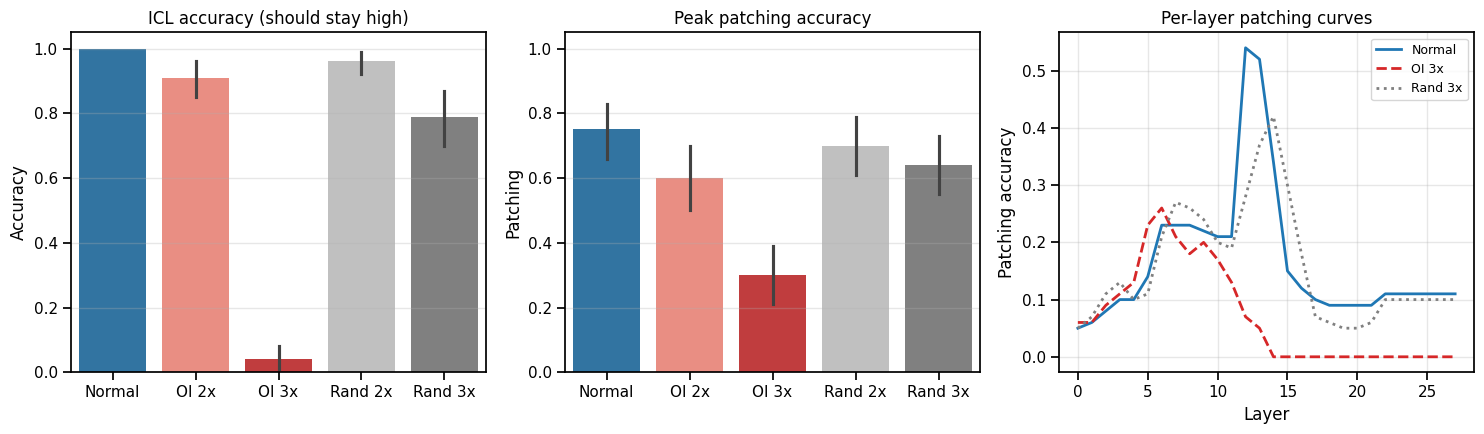


Group           n Norm patch    OI 2x    OI 3x  Rand 2x  Rand 3x
------------------------------------------------------------
survives       31      0.710    0.645    0.194    0.677    0.645
fails          69      0.768    0.580    0.348    0.710    0.638

ICL accuracy check (should remain high):
  survives: normal=1.000  oi_2x=0.935  oi_3x=0.000
  fails: normal=1.000  oi_2x=0.899  oi_3x=0.058


In [46]:
# === Plot amplification results (with error bars) ===

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: ICL accuracy
ax = axes[0]
conditions = ['normal', 'oi_2x', 'oi_3x', 'rand_2x', 'rand_3x']
labels = ['Normal', 'OI 2x', 'OI 3x', 'Rand 2x', 'Rand 3x']
colors = ['tab:blue', 'salmon', 'tab:red', 'silver', 'gray']
plot_rows = []
for _, row in df_amp.iterrows():
    for c, l in zip(conditions, labels):
        plot_rows.append({'Condition': l, 'Accuracy': row[f'{c}_icl']})
pdf = pd.DataFrame(plot_rows)
sns.barplot(data=pdf, x='Condition', y='Accuracy', order=labels,
            palette=dict(zip(labels, colors)), errorbar=('ci', 95), ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title('ICL accuracy (should stay high)')
ax.set_xlabel('')
ax.grid(True, alpha=0.3, axis='y')

# Panel 2: Peak patching accuracy
ax = axes[1]
plot_rows2 = []
for _, row in df_amp.iterrows():
    for c, l in zip(conditions, labels):
        plot_rows2.append({'Condition': l, 'Patching': row[f'{c}_patch']})
pdf2 = pd.DataFrame(plot_rows2)
sns.barplot(data=pdf2, x='Condition', y='Patching', order=labels,
            palette=dict(zip(labels, colors)), errorbar=('ci', 95), ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title('Peak patching accuracy')
ax.set_xlabel('')
ax.grid(True, alpha=0.3, axis='y')

# Panel 3: Patching curves for normal vs OI 3x
ax = axes[2]
for cond, label, color, ls in [
    ('normal', 'Normal', 'tab:blue', '-'),
    ('oi_3x', 'OI 3x', 'tab:red', '--'),
    ('rand_3x', 'Rand 3x', 'gray', ':'),
]:
    curves = np.array([r[f'{cond}_curve'] for r in amp_results])
    ax.plot(PATCH_LAYERS_AMP, curves.mean(axis=0), color=color, lw=2, ls=ls, label=label)
ax.set_xlabel('Layer')
ax.set_ylabel('Patching accuracy')
ax.set_title('Per-layer patching curves')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Summary by group
print(f'\n{"Group":<12s} {"n":>4s} {"Norm patch":>10s} {"OI 2x":>8s} {"OI 3x":>8s} '
      f'{"Rand 2x":>8s} {"Rand 3x":>8s}')
print('-' * 60)
for grp in ['survives', 'fails']:
    sub = df_amp[df_amp['group'] == grp]
    if len(sub) == 0: continue
    print(f'{grp:<12s} {len(sub):>4d} {sub["normal_patch"].mean():>10.3f} '
          f'{sub["oi_2x_patch"].mean():>8.3f} {sub["oi_3x_patch"].mean():>8.3f} '
          f'{sub["rand_2x_patch"].mean():>8.3f} {sub["rand_3x_patch"].mean():>8.3f}')

# ICL accuracy check
print(f'\nICL accuracy check (should remain high):')
for grp in ['survives', 'fails']:
    sub = df_amp[df_amp['group'] == grp]
    if len(sub) == 0: continue
    print(f'  {grp}: normal={sub["normal_icl"].mean():.3f}  '
          f'oi_2x={sub["oi_2x_icl"].mean():.3f}  '
          f'oi_3x={sub["oi_3x_icl"].mean():.3f}')

Prompts correct under all 2x conditions: 89/100

=== UNFILTERED ===
survives (n=31):  normal=0.710  oi_2x=0.645  rand_2x=0.677  OI_drop=+0.065  rand_drop=+0.032  OI_specific=+0.032
fails (n=69):  normal=0.768  oi_2x=0.580  rand_2x=0.710  OI_drop=+0.188  rand_drop=+0.058  OI_specific=+0.130

=== FILTERED (correct under all conditions) ===
survives (n=29):  normal=0.724  oi_2x=0.655  rand_2x=0.690  OI_drop=+0.069  rand_drop=+0.034  OI_specific=+0.034
fails (n=60):  normal=0.767  oi_2x=0.550  rand_2x=0.717  OI_drop=+0.217  rand_drop=+0.050  OI_specific=+0.167


/tmp/ipykernel_329549/1206948886.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sdf, x='Group', y='Specific effect',


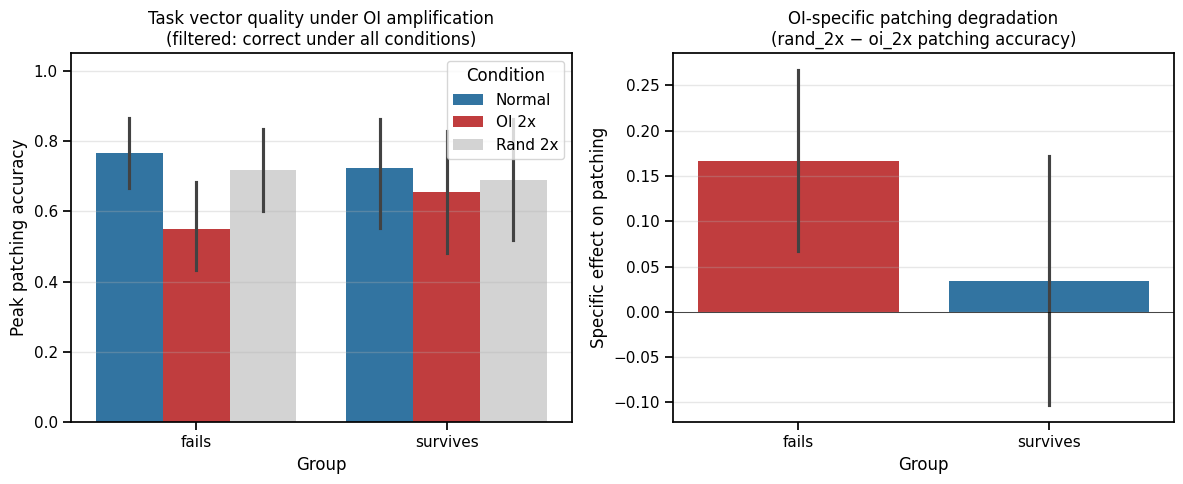

In [45]:
# === Amplification analysis: grouped by survive/fail ===

# Filter to prompts correct under normal, oi_2x, and rand_2x
clean = df_amp[(df_amp['normal_icl'] == 1) & 
               (df_amp['oi_2x_icl'] == 1) & 
               (df_amp['rand_2x_icl'] == 1)]

print(f'Prompts correct under all 2x conditions: {len(clean)}/{len(df_amp)}')
print()

# Unfiltered summary
print('=== UNFILTERED ===')
for grp in ['survives', 'fails']:
    sub = df_amp[df_amp['group'] == grp]
    if len(sub) == 0: continue
    nm = sub['normal_patch'].mean()
    oi = sub['oi_2x_patch'].mean()
    rd = sub['rand_2x_patch'].mean()
    print(f'{grp} (n={len(sub)}):  normal={nm:.3f}  oi_2x={oi:.3f}  rand_2x={rd:.3f}  '
          f'OI_drop={nm-oi:+.3f}  rand_drop={nm-rd:+.3f}  '
          f'OI_specific={rd-oi:+.3f}')

print()

# Filtered summary
print('=== FILTERED (correct under all conditions) ===')
for grp in ['survives', 'fails']:
    sub = clean[clean['group'] == grp]
    if len(sub) == 0: continue
    nm = sub['normal_patch'].mean()
    oi = sub['oi_2x_patch'].mean()
    rd = sub['rand_2x_patch'].mean()
    print(f'{grp} (n={len(sub)}):  normal={nm:.3f}  oi_2x={oi:.3f}  rand_2x={rd:.3f}  '
          f'OI_drop={nm-oi:+.3f}  rand_drop={nm-rd:+.3f}  '
          f'OI_specific={rd-oi:+.3f}')

# === Grouped bar plot (2x only, filtered) ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Patching accuracy by group (filtered)
ax = axes[0]
plot_rows = []
for _, row in clean.iterrows():
    plot_rows.append({'Group': row['group'], 'Condition': 'Normal', 'Peak': row['normal_patch']})
    plot_rows.append({'Group': row['group'], 'Condition': 'OI 2x', 'Peak': row['oi_2x_patch']})
    plot_rows.append({'Group': row['group'], 'Condition': 'Rand 2x', 'Peak': row['rand_2x_patch']})
pdf = pd.DataFrame(plot_rows)
sns.barplot(data=pdf, x='Group', y='Peak', hue='Condition',
            palette={'Normal': 'tab:blue', 'OI 2x': 'tab:red', 'Rand 2x': 'lightgray'},
            errorbar=('ci', 95), ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title('Task vector quality under OI amplification\n(filtered: correct under all conditions)')
ax.set_ylabel('Peak patching accuracy')
ax.grid(True, alpha=0.3, axis='y')

# Panel 2: Specific effect (rand_2x - oi_2x) by group
ax = axes[1]
spec_rows = []
for _, row in clean.iterrows():
    spec_rows.append({'Group': row['group'], 
                      'Specific effect': row['rand_2x_patch'] - row['oi_2x_patch']})
sdf = pd.DataFrame(spec_rows)
sns.barplot(data=sdf, x='Group', y='Specific effect',
            palette={'survives': 'tab:blue', 'fails': 'tab:red'},
            errorbar=('ci', 95), ax=ax)
ax.axhline(0, color='black', lw=0.5)
ax.set_title('OI-specific patching degradation\n(rand_2x − oi_2x patching accuracy)')
ax.set_ylabel('Specific effect on patching')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()